### CHURN ANALYSIS PROJECT

### Gereken kütüphaneleri Import etme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


### Veri yükleme ve EDA

In [2]:
# 1. Adım: Veriyi dataframe formatında yükleme
df = pd.read_csv("churn_data.csv")

In [3]:
# 2. Adım: Veriyi inceleme
print(f"Veri setinin satır (gözlem) sayısı: {df.shape[0]}")
print(f"Veri setinin sütun (değişken) sayısı: {df.shape[1]}")

Veri setinin satır (gözlem) sayısı: 1000
Veri setinin sütun (değişken) sayısı: 8


In [4]:
print(f"Veri setinin ilk 5 satırı:\n{df.head()}")

Veri setinin ilk 5 satırı:
  customer_id   age  gender  tenure  monthly_spend  num_purchases  \
0       C0001  56.0    Male      58         111.70             40   
1       C0002  46.0  Female      23         290.89              4   
2       C0003  32.0  Female      26         146.84             47   
3       C0004  60.0  Female      34          55.45             31   
4       C0005  25.0    Male      46         158.54             28   

   support_calls  churn  
0              4      0  
1              2      0  
2              5      0  
3              5      1  
4              7      0  


In [5]:
print({df.info()})

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    1000 non-null   str    
 1   age            970 non-null    float64
 2   gender         1000 non-null   str    
 3   tenure         1000 non-null   int64  
 4   monthly_spend  960 non-null    float64
 5   num_purchases  1000 non-null   int64  
 6   support_calls  1000 non-null   int64  
 7   churn          1000 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 62.6 KB
{None}


In [6]:
print(f"Veri setindeki boş hücreye sahip sütunlar:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Veri setindeki boş hücreye sahip sütunlar:
age              30
monthly_spend    40
dtype: int64


In [7]:
print(df.describe())

              age      tenure  monthly_spend  num_purchases  support_calls  \
count  970.000000  1000.00000     960.000000    1000.000000    1000.000000   
mean    41.040206    28.77700     274.648135      25.228000       4.462000   
std     13.509215    16.80636     129.771688      14.443013       2.885981   
min     18.000000     1.00000      50.060000       1.000000      -1.000000   
25%     29.000000    14.00000     166.605000      13.000000       2.000000   
50%     42.000000    28.00000     276.865000      26.000000       5.000000   
75%     52.000000    43.00000     388.282500      38.000000       7.000000   
max     64.000000    59.00000     499.260000      49.000000       9.000000   

             churn  
count  1000.000000  
mean      0.284000  
std       0.451162  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max       1.000000  


### EDA SONUÇ
* Veri seti 1000 satır ve 8 sütun'dan oluşuyor.
* age sütununda 30 ve monthly_spend sütununda 40 boş hücre var.
* support_calls sütununda negatif değerler var. Müşterilerin müşteri hizmetlerini arama sayısı negatif olamayacağından bu satırları veri setinden sileceğiz.
### Sütunların Anlamı
* customer_id    >> müşteri kimlik numarası
* age            >> müşterinin yaşı
* gender         >> müşterinin cinsiyeti
* tenure         >> müşterinin kaç aydır şirketin müşterisi olduğu
* monthly_spend  >> müşterinin aylık ortalama harcaması
* num_purchases  >> müşterinin toplam satın alma sayısı
* support_calls  >> müşterinin müşteri hizmetlerini kaç kez aradığı
* churn          >> 0:şirkette kalmış, 1:şirketi terk etmiş

### Veri Seti Temizleme ve Feature Engineering

In [8]:
# support_calls sütunundaki negatif değerler yanlış veri olduğu için bu satırları siliyoruz.
cleaned_df = df[df["support_calls"] >= 0]
# güncel veri setinin satır sayısını kontrol ediyoruz
print(f"Veri setindeki yanlış veriler temizlendikten sonra satır sayısı: {cleaned_df.shape[0]}")

Veri setindeki yanlış veriler temizlendikten sonra satır sayısı: 980


In [9]:
# veri setindeki boş hücreleri doldurmak için öncelikle bu veri setlerinde aykırı değer olup olmadığını kontrol edeceğiz.
missing_columns = cleaned_df.columns[cleaned_df.isnull().any()].to_list() # öncelikle boş hücre içeren sütunları missing_columns değişkenine atıyoruz.

In [10]:
for col in missing_columns: # her bir boş hücre içeren sütun için aykırı değer kontrolü yapalım.
    Q1 = cleaned_df[col].quantile(0.25) # 1. çeyrek
    Q3 = cleaned_df[col].quantile(0.75) # 3. çeyrek
    IQR = Q3-Q1 
    lower_bound = (Q1) - (1.5 * IQR) # alt sınır
    upper_bound = (Q3) + (1.5*IQR) # üst sınır
    outliers = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)] # bir sütunda alt sınırdan küçük veya üst sınırdan büyük olan değerlere aykırı (outlier) denir. Boş hücreleri olan sütunlar için bu kontrolü yapıyoruz. 
    print(f"{col} sütunundaki aykırı değer sayısı: {len(outliers)}") # eğer bu sütunlarda aykırı değer varsa, boş hücreleri medyan ile dolduracağız. Çünkü medyan, aykırı değerlere karşı dayanıklıdır ancak bu sütunlarda aykırı değer yoksa ortalama ile dolduracağız. Ortalama, aykırı değerlere karşı duyarlı olduğundan bir sütunda aykırı değerler olduğunda bu sütunu ortalama ile doldurmak doğru değildir. 

age sütunundaki aykırı değer sayısı: 0
monthly_spend sütunundaki aykırı değer sayısı: 0


In [11]:
# iki sütunda da aykırı değer olmadığı için bu sütunlardaki boş hücreleri ortalama ile dolduruyoruz.
for col in missing_columns:
    mean = cleaned_df[col].mean()
    cleaned_df[col] = cleaned_df[col].fillna(mean)

In [12]:
# boş hücre kaldı mı kontrol edelim.
cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0]

Series([], dtype: int64)

In [13]:
# özellik türeteceğiz
cleaned_df["purchase_per_month"] = cleaned_df["num_purchases"] / cleaned_df["tenure"] # İlk özelliğimiz müşterilerin ay başına kaç kere satın alma işleminde bulunduğunu göstermek. Yüksek satın alma sıklığı, müşterinin şirketimize bağlı olduğunu gösterir.
cleaned_df["total_spend"] = cleaned_df["monthly_spend"] * cleaned_df["tenure"] # İkinci özelliğimiz müşterilerin toplam ne kadar harcama yaptığını göstermek. Bu özelliği ay başına ortalama harcama ile ilgili müşterinin kaç aydır müşterimiz olduğunu çarparak bulacağız. Yüksek satın alma tutarı da müşterinin şirketimize bağlılığını gösterir.
cleaned_df["support_calls_per_month"] = cleaned_df["support_calls"] / cleaned_df["tenure"] # Son özelliğimiz ise müşterilerin ay başına çağrı merkezini kaç kere aradığını göstermek. Yüksek ay başına aranan çağrı merkezi, müşterinin memnun olmadığını gösterebilirken düşük ay başına çağrı merkezini arama ise müşterinin ürünlerimizden memnun olduğunu gösterebilir.
print(cleaned_df.head())# veri setindeki yeni sütunları kontrol edelim

  customer_id   age  gender  tenure  monthly_spend  num_purchases  \
0       C0001  56.0    Male      58         111.70             40   
1       C0002  46.0  Female      23         290.89              4   
2       C0003  32.0  Female      26         146.84             47   
3       C0004  60.0  Female      34          55.45             31   
4       C0005  25.0    Male      46         158.54             28   

   support_calls  churn  purchase_per_month  total_spend  \
0              4      0            0.689655      6478.60   
1              2      0            0.173913      6690.47   
2              5      0            1.807692      3817.84   
3              5      1            0.911765      1885.30   
4              7      0            0.608696      7292.84   

   support_calls_per_month  
0                 0.068966  
1                 0.086957  
2                 0.192308  
3                 0.147059  
4                 0.152174  


<Axes: >

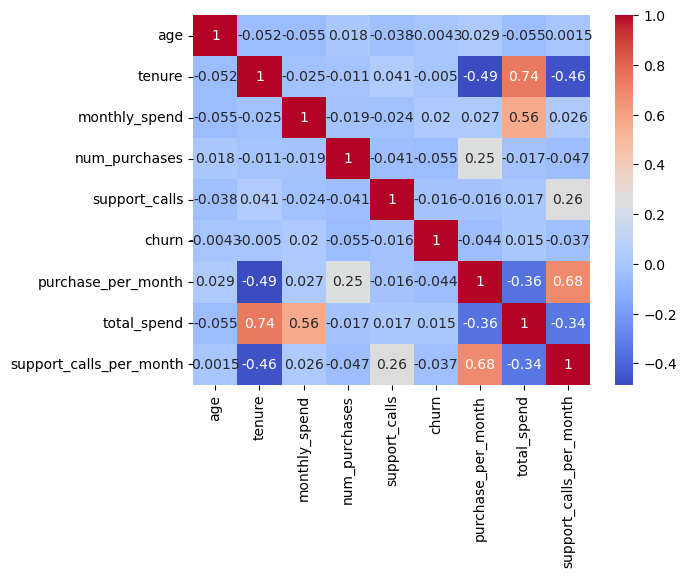

In [14]:
correlation = cleaned_df.corr(numeric_only=True)
# korelasyon matrisini görselleştirelim
sns.heatmap(data=correlation, annot=True, cmap="coolwarm")

### MODEL KURMA

In [15]:
cleaned_df["gender"] = cleaned_df["gender"].map({"Male": 1, "Female": 0}) # Makine öğrenmesi algoritmalarında cinsiyet gibi kategorik değişkenler bilgisayarın anlayabilmesi için encode edilmelidir. Burada erkeklere 1, kadınlara ise 0 atayarak cinsiyet değişkenini encode ediyoruz.

In [16]:
# customer_id sütunu, müşterileri benzersiz şekilde tanımlayan bir kimlik numarasıdır ve bu sütun modelleme için anlamlı bir bilgi içermediği için bu sütunu veri setinden çıkarıyoruz.
cleaned_df = cleaned_df.drop(columns=["customer_id"])

In [17]:
# veri setimizi kontrol edelim.
cleaned_df.head()

,age,gender,tenure,monthly_spend,num_purchases,support_calls,churn,purchase_per_month,total_spend,support_calls_per_month
0,56.0,1,58,111.70,40,4,0,0.689655,6478.60,0.068966
1,46.0,0,23,290.89,4,2,0,0.173913,6690.47,0.086957
2,32.0,0,26,146.84,47,5,0,1.807692,3817.84,0.192308
3,60.0,0,34,55.45,31,5,1,0.911765,1885.30,0.147059
4,25.0,1,46,158.54,28,7,0,0.608696,7292.84,0.152174


In [18]:
X = cleaned_df.drop(columns=["churn"]) # bağımsız değişkenlerimizi X değişkenine atıyoruz. Bağımsız değişkenler, müşterinin cinsiyeti, yaşı, satın alma sıklığı gibi müşteriyi tanımlayan özelliklerdir.
y = cleaned_df["churn"] # bağımlı değişkenimizi y değişkenine atıyoruz. Bağımlı değişken, müşterinin şirketimizden ayrılıp ayrılmadığını gösteren churn sütunudur. Bu sütunda 1 değeri müşterinin şirketimizden ayrıldığını, 0 değeri ise müşterinin şirketimizde kaldığını gösterir. Modelleme yaparken bağımsız değişkenlerimizi kullanarak bağımlı değişkeni tahmin etmeye çalışacağız.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # veri setimizi eğitim ve test seti olarak ayırıyoruz. Eğitim seti, modelimizi eğitmek için kullanacağımız veri setidir. Test seti ise modelimizin performansını değerlendirmek için kullanacağımız veri setidir. Test setinin boyutu genellikle %20 olarak belirlenir. random_state parametresi ise veri setini bölme işleminin her seferinde aynı şekilde yapılmasını sağlar. Böylece modelimizin performansını karşılaştırırken aynı test setini kullanarak daha adil bir karşılaştırma yapabiliriz.

In [20]:
print(f"Eğitim setindeki gözlem sayısı:{len(X_train)}")
print(f"Test setindeki gözlem sayısı:{len(X_test)}")

Eğitim setindeki gözlem sayısı:784
Test setindeki gözlem sayısı:196


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) # age ve total_spend gibi bazı bağımsız değişkenlerimizin ölçekleri birbirinden farklıdır. Bu durum bazı makine öğrenmesi algoritmalarının performansını olumsuz etkileyebilir. Bu nedenle bu bağımsız değişkenleri standartlaştırarak aynı ölçeğe getireceğiz. StandardScaler, veriyi ortalaması 0 ve standart sapması 1 olacak şekilde dönüştürür. 
X_test_scaled = scaler.transform(X_test) # Öncelikle eğitim setimizi kullanarak scaler'ı fit ediyoruz ve ardından bu scaler'ı kullanarak eğitim setimizi dönüştürüyoruz.

In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight="balanced") # Bir lojistik regresyon modeli oluşturuyoruz.
model.fit(X_train_scaled, y_train) # Oluşturduğumuz modeli eğitim verisi üzerinde eğitiyoruz.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [28]:
y_pred = model.predict(X_test_scaled) # Modelimizin başarısını ölçmek için test seti üzerinden sınav yapıyoruz.
from sklearn.metrics import classification_report 

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.39      0.47       127
           1       0.30      0.48      0.37        69

    accuracy                           0.42       196
   macro avg       0.44      0.44      0.42       196
weighted avg       0.48      0.42      0.43       196



### Model Sonuç
* Modelimizin churn olacak dediği kişilerin %30'u churn olmuş. Modelimizin churn olmayacak dediği kişilerin yüzde %58'i churn olmamış. Model gerçekten churn olmayan kişilerin yüzde %39'unu bulmuş ancak model gerçekten churn olan kişilerin ise %48'ini bulmuş."
* Modelimiz churn riskli müşterilerin yarısını buluyor. Modelimizin churn riskini bulamadığı müşterilerimizin yarısı şirketten ayrılıyor ve biz bunu önleyemiyoruz. Modelimizin performansını güçlendirmek için daha fazla ve daha kaliteli veriye ihtiyacımız var.
* Şirkete önerim churn riskini doğrudan etkileyen açıklayabilen verileri toplamamız. Bu veriler ne olabilir ? Müşterilerin en son ne zaman alışveriş yaptığı (recency), müşterilerin uygulamaya kayıtlarının devam edip etmediği bilgisi. Bu iki bilginin churn tahminlerinde kritik yol oynayacağı kanaatindeyim